# 👨🏻‍💻 **Team Notebook — NASA Software Defect Prediction Challenge**
## 🤖 **Machine Learning Challenge** 🤖

---

## **The Challenge**

You receive **software metrics extracted from real NASA mission code**.
Build a classifier that predicts whether a software module contains bugs.

This is a **real industry problem** — companies like NASA, Google and Microsoft
use ML to prioritise code review before releases.

---

## **Your Files**

| File                  | Description                        | Use                   |
|-----------------------|------------------------------------|-----------------------|
| `cm1.csv`             | Scientific instrument (spacecraft) | Training / Validation |
| `pc1.csv`             | Flight software (Earth satellite)  | Training / Validation |
| `jm1.csv`             | Real-time ground system (large)    | Training / Validation |
| `kc1.csv`             | Storage management system          | Training / Validation |
| `kc2_test_blind.csv`  | Secret mission — **no labels**     | Predict & Submit      |

---

## **What You Submit**

A file named **`predictions_TEAMNAME.csv`**:

```
id,defects
0,0
1,1
2,0
```

- `id` — row index (0 to 521)
- `defects` — **1 = buggy**, **0 = clean**

---

## **Scenario Details**

| Training Data             | Test Data   |
|---------------------------|-------------|
| CM1 / PC1 / JM1 / KC1     | KC2         |
| ...                       | ...         |

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report, confusion_matrix
)
from sklearn.preprocessing import RobustScaler
from xgboost import XGBClassifier

DATASETS_DIR   = "datasets/datasets"
TESTBLIND_PATH = "test-blind/test-blind/kc2_test_blind.csv"
TEAM_NAME      = "TEAMNAME"

# ── Load training sets ──────────────────────────────────────────────────────
files = ["cm1.csv", "pc1.csv", "jm1.csv", "kc1.csv"]
dfs   = []
for fname in files:
    df = pd.read_csv(f"{DATASETS_DIR}/{fname}")
    df.columns = df.columns.str.lower()          # normalise column names
    df["source"] = fname.replace(".csv", "")
    dfs.append(df)

train_raw = pd.concat(dfs, ignore_index=True)
print("Combined training shape:", train_raw.shape)
train_raw.head(3)


Combined training shape: (16920, 23)


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,...,locomment,loblank,loccodeandcomment,uniq_op,uniq_opnd,total_op,total_opnd,branchcount,defects,source
0,1.1,1.4,1.4,1.4,1.3,1.30,1.30,1.3,1.30,1.30,...,2,2,2,1.2,1.2,1.2,1.2,1.4,False,cm1
1,1.0,1.0,1.0,1.0,1.0,1.00,1.00,1.0,1.00,1.00,...,1,1,1,1.0,1.0,1.0,1.0,1.0,True,cm1
2,24.0,5.0,1.0,3.0,63.0,309.13,0.11,9.5,32.54,2936.77,...,0,6,0,15.0,15.0,44.0,19.0,9.0,False,cm1


## 🔍 Exploratory Data Analysis

Class distribution (training):
defects
False    14365
True      2555
Name: count, dtype: int64
Imbalance ratio: 5.62:1


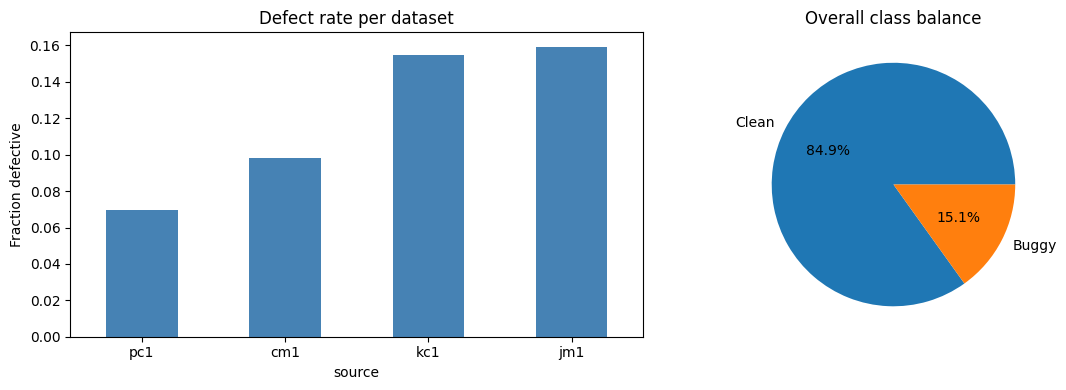


Feature statistics:


,loc,v(g),ev(g),iv(g),n,v,l,d,i,e,b,t,locode,locomment,loblank,uniq_op,uniq_opnd,total_op,total_opnd,branchcount
count,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00,16920.00
mean,35.91,5.57,2.97,3.62,103.10,599.28,0.17,13.13,28.38,29834.54,0.20,1657.47,22.98,2.81,4.46,10.87,15.91,61.38,41.81,9.81
std,65.82,11.24,5.99,7.83,219.83,1681.51,0.20,17.42,31.86,358567.59,0.56,19920.42,50.91,9.51,9.98,9.19,24.53,133.15,88.66,19.74
min,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,9.00,1.00,1.00,1.00,13.00,41.51,0.04,3.00,11.36,129.72,0.01,7.21,3.00,0.00,0.00,5.00,4.00,8.00,5.00,1.00
50%,19.00,3.00,1.00,2.00,43.00,188.87,0.09,8.36,20.94,1647.46,0.06,91.53,11.00,0.00,2.00,10.00,10.00,26.00,17.00,5.00
75%,40.00,6.00,3.00,4.00,111.00,566.61,0.21,17.35,35.93,9617.60,0.19,534.31,25.00,2.00,5.00,15.00,20.00,66.00,44.00,11.00
max,3442.00,470.00,165.00,402.00,8441.00,80843.08,2.00,418.20,598.33,31079782.27,26.95,1726654.57,2824.00,344.00,447.00,411.00,1026.00,5420.00,3021.00,826.00


In [2]:
# ── Exploratory Data Analysis ───────────────────────────────────────────────
print("Class distribution (training):")
print(train_raw["defects"].value_counts())
print(f"Imbalance ratio: {train_raw['defects'].value_counts()[False]/train_raw['defects'].value_counts()[True]:.2f}:1")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Per-dataset defect rate
defect_rates = pd.concat([
    pd.read_csv(f"{DATASETS_DIR}/{f}").assign(source=f.replace('.csv',''))
    for f in ["cm1.csv", "pc1.csv", "jm1.csv", "kc1.csv"]
])
defect_rates.columns = defect_rates.columns.str.lower()
rates = defect_rates.groupby("source")["defects"].mean().sort_values()
rates.plot(kind="bar", ax=axes[0], color="steelblue", title="Defect rate per dataset")
axes[0].set_ylabel("Fraction defective")
axes[0].tick_params(axis="x", rotation=0)

# Overall class balance
train_raw["defects"].value_counts().plot(
    kind="pie", ax=axes[1], autopct="%1.1f%%",
    labels=["Clean", "Buggy"], title="Overall class balance"
)
plt.tight_layout()
plt.savefig("eda_class_balance.png", dpi=100)
plt.show()

# Feature distributions (first numeric columns)
feature_cols = [c for c in train_raw.columns
                if c not in ("defects", "source", "loccodeandcomment")]
print("\nFeature statistics:")
train_raw[feature_cols].describe().round(2)


## ⚙️ Preprocessing

In [3]:
# ── Preprocessing ───────────────────────────────────────────────────────────
# Drop 'loccodeandcomment' — absent in the test set
# Drop 'source' helper column
DROP_COLS = ["loccodeandcomment", "source"]

FEATURE_COLS = [
    c for c in train_raw.columns
    if c not in DROP_COLS + ["defects"]
]

X_train = train_raw[FEATURE_COLS].copy()
y_train = train_raw["defects"].astype(int)

# ── Load test set ────────────────────────────────────────────────────────────
test_raw = pd.read_csv(TESTBLIND_PATH)
test_raw.columns = test_raw.columns.str.lower()
test_ids = test_raw["id"].values
X_test   = test_raw[FEATURE_COLS].copy()

# ── Scale features with RobustScaler (handles outliers well) ─────────────────
scaler  = RobustScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print("Training feature matrix:", X_train_sc.shape)
print("Test feature matrix    :", X_test_sc.shape)
print("Positive rate (train)  :", y_train.mean().round(4))

# Check for missing values
print("NaN in train:", np.isnan(X_train_sc).sum())
print("NaN in test :", np.isnan(X_test_sc).sum())


Training feature matrix: (16920, 20)
Test feature matrix    : (522, 20)
Positive rate (train)  : 0.151
NaN in train: 0
NaN in test : 0


## 🚀 XGBoost Model Training

In [4]:
# ── XGBoost — Cross-Validated Training ──────────────────────────────────────
# scale_pos_weight compensates for class imbalance
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight = {scale_pos_weight:.2f}  (neg={neg}, pos={pos})")

xgb = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

roc_scores = cross_val_score(xgb, X_train_sc, y_train, cv=cv,
                              scoring="roc_auc", n_jobs=-1)
f1_scores  = cross_val_score(xgb, X_train_sc, y_train, cv=cv,
                              scoring="f1", n_jobs=-1)

print(f"\n5-Fold CV ROC-AUC : {roc_scores.mean():.4f} ± {roc_scores.std():.4f}")
print(f"5-Fold CV F1       : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")

# ── Final model on full training data ────────────────────────────────────────
xgb.fit(X_train_sc, y_train)
print("\nModel trained on full training set.")


scale_pos_weight = 5.62  (neg=14365, pos=2555)



5-Fold CV ROC-AUC : 0.7609 ± 0.0112
5-Fold CV F1       : 0.4259 ± 0.0116



Model trained on full training set.


## 📊 Feature Importance

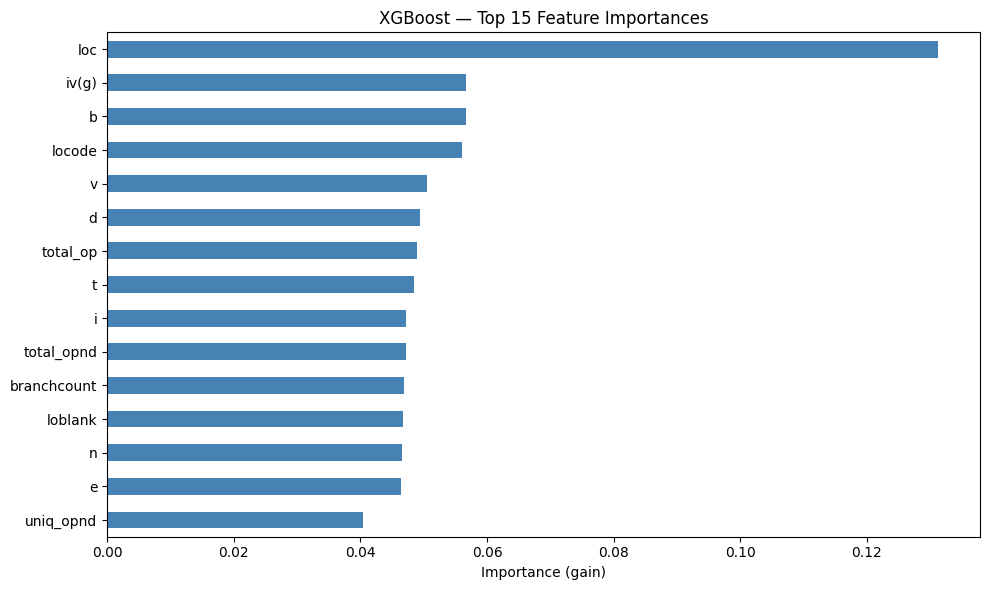

Top 10 features:
loc           0.131317
iv(g)         0.056725
b             0.056646
locode        0.055995
v             0.050451
d             0.049468
total_op      0.049004
t             0.048519
i             0.047199
total_opnd    0.047143


In [5]:
# ── Feature Importance ──────────────────────────────────────────────────────
importances = pd.Series(xgb.feature_importances_, index=FEATURE_COLS)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances_sorted.head(15).plot(kind="barh", color="steelblue")
plt.gca().invert_yaxis()
plt.title("XGBoost — Top 15 Feature Importances")
plt.xlabel("Importance (gain)")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=100)
plt.show()

print("Top 10 features:")
print(importances_sorted.head(10).to_string())


## 🧪 Cross-Dataset Evaluation

In [6]:
# ── Per-source evaluation (leave-one-out) ───────────────────────────────────
# Useful to understand cross-dataset generalisation
results = []
source_dfs = {}
for fname in ["cm1.csv", "pc1.csv", "jm1.csv", "kc1.csv"]:
    df = pd.read_csv(f"{DATASETS_DIR}/{fname}")
    df.columns = df.columns.str.lower()
    source_dfs[fname.replace('.csv','')] = df

for held_out in source_dfs:
    # Train on the other 3
    train_src = pd.concat(
        [df for name, df in source_dfs.items() if name != held_out],
        ignore_index=True
    )
    X_s = scaler.fit_transform(train_src[FEATURE_COLS])
    y_s = train_src["defects"].astype(int)

    val_src = source_dfs[held_out]
    X_v = scaler.transform(val_src[FEATURE_COLS])
    y_v = val_src["defects"].astype(int)

    neg_s, pos_s = (y_s == 0).sum(), (y_s == 1).sum()
    clf = XGBClassifier(
        n_estimators=500, max_depth=5, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=neg_s/pos_s,
        eval_metric="logloss", use_label_encoder=False,
        random_state=42, n_jobs=-1
    )
    clf.fit(X_s, y_s)
    y_prob = clf.predict_proba(X_v)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)
    results.append({
        "held_out": held_out,
        "ROC-AUC": round(roc_auc_score(y_v, y_prob), 4),
        "F1":      round(f1_score(y_v, y_pred), 4),
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))


held_out  ROC-AUC     F1
     cm1   0.7966 0.4000
     pc1   0.7082 0.2460
     jm1   0.6010 0.2956
     kc1   0.7418 0.3266


## 📤 Generate Predictions

In [7]:
# ── Generate Predictions for kc2 ───────────────────────────────────────────
# Re-fit scaler on full training set before predicting
scaler_final = RobustScaler()
X_train_final = scaler_final.fit_transform(X_train)
X_test_final  = scaler_final.transform(X_test)

# Re-train model with full training set using final scaler
xgb_final = XGBClassifier(
    n_estimators=500,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
)
xgb_final.fit(X_train_final, y_train)

# Predict
y_pred_test = xgb_final.predict(X_test_final)
y_prob_test = xgb_final.predict_proba(X_test_final)[:, 1]

predictions = pd.DataFrame({"id": test_ids, "defects": y_pred_test})
out_path = f"predictions_{TEAM_NAME}.csv"
predictions.to_csv(out_path, index=False)

print(f"Predictions saved to: {out_path}")
print(f"Total samples predicted: {len(predictions)}")
print(f"Predicted buggy   (1): {(y_pred_test == 1).sum()}")
print(f"Predicted clean   (0): {(y_pred_test == 0).sum()}")
print(f"Defect rate: {y_pred_test.mean():.2%}")
print()
print("First 10 predictions:")
print(predictions.head(10).to_string(index=False))


Predictions saved to: predictions_TEAMNAME.csv
Total samples predicted: 522
Predicted buggy   (1): 150
Predicted clean   (0): 372
Defect rate: 28.74%

First 10 predictions:
 id  defects
  0        0
  1        1
  2        1
  3        1
  4        1
  5        1
  6        1
  7        0
  8        0
  9        0
